In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 

from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

from jax import vmap, Array
import tensorflow as tf
os.environ["CUDA_VISIBLE_DEVICES"]="1"

2025-02-20 10:34:22.571600: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740047662.583730  490763 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740047662.587582  490763 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

In [53]:
normconsts = np.load('../grids/Chiara-normconsts.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 2

dense_layer_units = 512

Nepochs = 200000

learning_rate = 0.001

model_name = 'logLPhot'

loss_func = 'MSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':'logLPhot', 'n_dense_layers':2, 'dense_layer_units':512, 'Nepochs':200000, 'lrate':0.001, \
        'loss':'MSE', 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'age', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'numax', 'dnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir}

model_outputs = Emulator(emulator_kwargs, normalised = False)

num_stars = 100

In [54]:
df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df')

df_full['logLPhot'] = np.log10(df_full['LPhot'])

inputs = model_outputs.inputs

outputs = ['FeH', 'LPhot', 'Teff', 'numax', 'dnuSer']

hierarchical_params = ['mu_zini', 'std_zini', 'mu_alphaMLT', 'std_alphaMLT', 'mu_age', 'std_age']

df = df_full[inputs+outputs+['logLPhot']]

normconsts['LPhot'] = (np.min(df_full['LPhot']), np.max(df_full['LPhot']))

#Then I pick a hare - I need to try with an emu instead, this was just quick to make sure the sampling runs at al

seed = 42

df_train = df.sample(frac=0.95, random_state=seed)

df_test = df.drop(df_train.index)

In [68]:
prior_values = [11000]

prior_widths = [50]



priors = [(prior_values[i], prior_widths[i]) for i in range(len(prior_values))]

cluster_consts = {}

for key, value in zip(['age'], priors):
    if key not in cluster_consts:
        cluster_consts[key] = value
    else:
        cluster_consts[key].append(value)
cluster_consts

{'age': (11000, 50)}

# Make a fake cluster

In [69]:
def fake_stars(uncs, consts = cluster_consts, obs = model_outputs.obs_dict):

    with numpyro.plate("star", 1):

        age = numpyro.sample('age', dist.Normal(consts['age'][0], consts['age'][1]))


# Prior Predictive Test

In [57]:
phys_unc = {'Teff':150, 'LPhot':4, 'numax': 10/3090, 'dnuSer':1/135, 'FeH':0.1}
#uncert = jnp.array([phys_unc[i] for i in outputs])*jnp.ones_like(jnp.array(df_obs[outputs]))

In [58]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

prior_predictive = Predictive(fake_stars, num_samples=num_stars,)

prior = prior_predictive(rng_key_, \
                         uncs=phys_unc, )


(array([ 4.,  3.,  5., 19., 17., 18., 14., 14.,  2.,  4.]),
 array([10863.55957031, 10890.31933594, 10917.08007812, 10943.83984375,
        10970.60058594, 10997.36035156, 11024.12011719, 11050.88085938,
        11077.640625  , 11104.40136719, 11131.16113281]),
 <BarContainer object of 10 artists>)

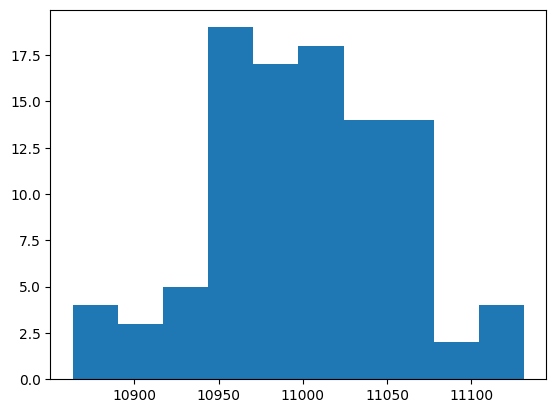

In [59]:
plt.hist(prior['age'])

In [60]:
cluster_df = pd.DataFrame(columns = df_test.columns)

df_test = df.drop(df_train.index)

df_test = df_test[df_test['alphaFe'] == 0]

for i in range(num_stars):

    distance = (df_test['age'] - prior['age'][i])**2

    
    idx_min = distance.sort_values(ascending = True).index[0]

    cluster_df.loc[i] = df_test.loc[idx_min]

    df_test = df_test.drop(index = idx_min)


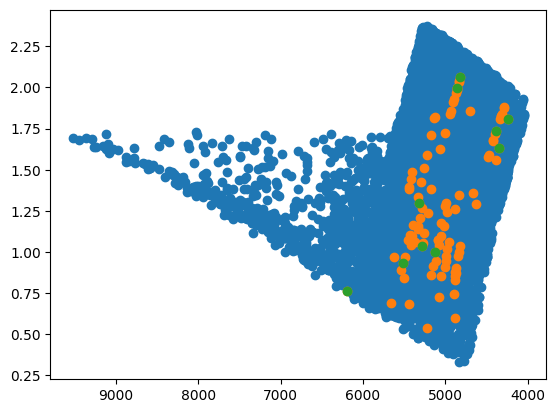

In [87]:
cluster_s = cluster_df.sample(10)

plt.scatter(df_test['Teff'], df_test['logLPhot'])
plt.scatter(cluster_df['Teff'], cluster_df['logLPhot'])
plt.scatter(cluster_s['Teff'], cluster_s['logLPhot'])

plt.gca().invert_xaxis()

(array([ 4.,  3.,  5., 19., 17., 18., 14., 14.,  2.,  4.]),
 array([10863.55957031, 10890.31933594, 10917.08007812, 10943.83984375,
        10970.60058594, 10997.36035156, 11024.12011719, 11050.88085938,
        11077.640625  , 11104.40136719, 11131.16113281]),
 <BarContainer object of 10 artists>)

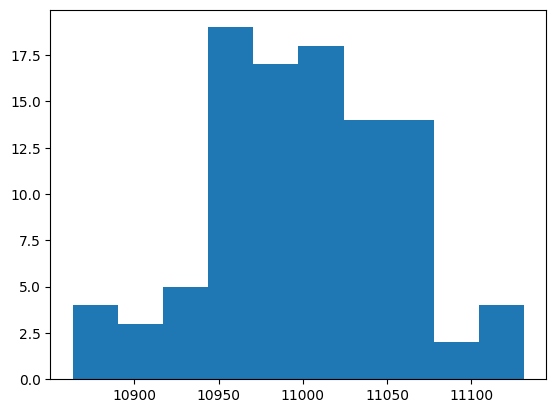

In [88]:

plt.hist(prior['age'])
#plt.hist(cluster_df['age'],)


In [89]:
emu_data = model_outputs(cluster_s[model_outputs.inputs])

obs_dict_values = [emu_data.T[i] for i in range(len(model_outputs.outputs))]


obs_dict = {}

for key, value in zip(model_outputs.outputs, obs_dict_values):
    if key not in obs_dict:
        obs_dict[key] = value
    else:
        obs_dict[key].append(value)

obs_dict['LPhot'] = 10**(obs_dict['logLPhot'])

np.save('./fake-1param-observations-age.npy', obs_dict)

np.save('./fake-1param-consts-age.npy', cluster_consts)

In [90]:
cluster_s.to_csv('fake-1param-age-df.csv',)

(array([ 7.,  1., 42.,  2., 25.,  7.,  5.,  0.,  7.,  4.]),
 array([0.735 , 0.7768, 0.8186, 0.8604, 0.9022, 0.944 , 0.9858, 1.0276,
        1.0694, 1.1112, 1.153 ]),
 <BarContainer object of 10 artists>)

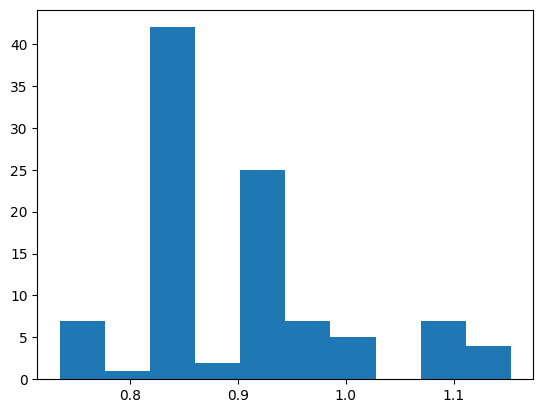

In [86]:
plt.hist(cluster_s['massini'])

In [85]:
np.mean(cluster_s['alphaFe'])


np.float64(0.0)

In [77]:
plt.hist(prior['zini'])

KeyError: 'zini'